<a href="https://colab.research.google.com/github/rishabhg46-bot/Data-Science/blob/main/A_Deep_Learning_Based_Multimodal_Biometric_Authentication_Framework_Using_Fingerprint_and_Iris_with_Score_Level_Fusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"rishabhg46","key":"3b882595eca8ba2b5f3ea8e1a1438c34"}'}

In [16]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [17]:
!kaggle datasets download -d ouaraskhelilrafik/iris-images

Dataset URL: https://www.kaggle.com/datasets/ouaraskhelilrafik/iris-images
License(s): other
iris-images.zip: Skipping, found more recently modified local copy (use --force to force download)


In [20]:
!unzip iris-images.zipy

Archive:  iris-images.zip
replace iris_images/iris17_24/left/017L_1.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: iris_images/iris17_24/left/017L_1.png  
  inflating: iris_images/iris17_24/left/017L_2.png  
  inflating: iris_images/iris17_24/left/017L_3.png  
  inflating: iris_images/iris17_24/left/018L_1.png  
  inflating: iris_images/iris17_24/left/018L_2.png  
  inflating: iris_images/iris17_24/left/018L_3.png  
  inflating: iris_images/iris17_24/left/019L_1.png  
  inflating: iris_images/iris17_24/left/019L_2.png  
  inflating: iris_images/iris17_24/left/019L_3.png  
  inflating: iris_images/iris17_24/left/020L_1.png  
  inflating: iris_images/iris17_24/left/020L_2.png  
  inflating: iris_images/iris17_24/left/020L_3.png  
  inflating: iris_images/iris17_24/left/021L_1.png  
  inflating: iris_images/iris17_24/left/021L_2.png  
  inflating: iris_images/iris17_24/left/021L_3.png  
  inflating: iris_images/iris17_24/left/022L_1.png  
  inflating: iris_images/iris17_24/left

In [21]:
!kaggle datasets download -d ruizgara/socofing

Dataset URL: https://www.kaggle.com/datasets/ruizgara/socofing
License(s): other
socofing.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip socofing.zip

In [22]:
import os
os.listdir()

['.config',
 'kaggle.json',
 'iris_images',
 'socofing',
 'kaggle (1).json',
 'SOCOFing',
 'socofing.zip',
 'iris-images.zip',
 'sample_data']

In [23]:
fingerprint_path = "/content/SOCOFing"
iris_path = "/content/iris_images"

In [24]:
import os

print(len(os.listdir(fingerprint_path)))
print(len(os.listdir(iris_path)))

2
8


In [25]:
import cv2
import numpy as np

IMG_SIZE = 128

def preprocess_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
    img = img/255.0
    return img

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

finger_model = Sequential([
Conv2D(32,(3,3),activation='relu',input_shape=(128,128,1)),
MaxPooling2D(),
Conv2D(64,(3,3),activation='relu'),
MaxPooling2D(),
Flatten(),
Dense(128,activation='relu'),
Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
iris_model = Sequential([
Conv2D(32,(3,3),activation='relu',input_shape=(128,128,1)),
MaxPooling2D(),
Conv2D(64,(3,3),activation='relu'),
MaxPooling2D(),
Flatten(),
Dense(128,activation='relu'),
Dense(10,activation='softmax')
])

In [32]:
import cv2
import numpy as np
import os

In [33]:
fingerprint_path = "/content/SOCOFing"
iris_path = "/content/iris_images"

In [35]:
!ls /content/SOCOFing

Altered  Real


In [36]:
!ls /content/SOCOFing/Real | head

100__M_Left_index_finger.BMP
100__M_Left_little_finger.BMP
100__M_Left_middle_finger.BMP
100__M_Left_ring_finger.BMP
100__M_Left_thumb_finger.BMP
100__M_Right_index_finger.BMP
100__M_Right_little_finger.BMP
100__M_Right_middle_finger.BMP
100__M_Right_ring_finger.BMP
100__M_Right_thumb_finger.BMP


In [37]:
fingerprint_path = "/content/SOCOFing/Real"

In [38]:
import cv2
import os
import numpy as np

fingerprint_path = "/content/SOCOFing/Real"

finger_files = os.listdir(fingerprint_path)

finger_img_path = os.path.join(fingerprint_path, finger_files[0])

print("Image path:", finger_img_path)

img = cv2.imread(finger_img_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Image not loaded. Check path.")
else:
    img = cv2.resize(img,(128,128))
    img = img/255.0
    finger_image = img.reshape(1,128,128,1)

print("Image loaded successfully")

Image path: /content/SOCOFing/Real/454__M_Right_thumb_finger.BMP
Image loaded successfully


In [39]:
finger_score = finger_model.predict(finger_image)

print("Fingerprint Score:", finger_score)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
Fingerprint Score: [[0.10570283 0.09205338 0.08791862 0.08985474 0.11429524 0.08490799
  0.11208994 0.09837855 0.11993261 0.09486615]]


In [40]:
import os
import cv2
import numpy as np

iris_path = "/content/iris_images"

iris_files = os.listdir(iris_path)

iris_img_path = os.path.join(iris_path, iris_files[0])

img = cv2.imread(iris_img_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img,(128,128))
img = img/255.0

iris_image = img.reshape(1,128,128,1)

print("Iris image loaded")

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


In [41]:
!ls /content/iris_images

iris17_24  iris25_32  iris41_48  iris57_64
iris1_8    iris33_40  iris49_56  iris9_16


In [42]:
iris_main_path = "/content/iris_images"

In [43]:
import os

folders = os.listdir(iris_main_path)

print(folders)

['iris25_32', 'iris49_56', 'iris33_40', 'iris17_24', 'iris1_8', 'iris41_48', 'iris9_16', 'iris57_64']


In [44]:
iris_folder = os.path.join(iris_main_path, folders[0])

In [45]:
import cv2
import numpy as np

iris_files = os.listdir(iris_folder)

iris_img_path = os.path.join(iris_folder, iris_files[0])

print("Image path:", iris_img_path)

img = cv2.imread(iris_img_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Image not loaded")
else:
    img = cv2.resize(img,(128,128))
    img = img/255.0
    iris_image = img.reshape(1,128,128,1)

print("Iris image loaded successfully")

Image path: /content/iris_images/iris25_32/left
Image not loaded
Iris image loaded successfully


In [46]:
finger_images = []

for file in os.listdir(fingerprint_path):

    img_path = os.path.join(fingerprint_path, file)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
    img = img/255.0

    finger_images.append(img)

finger_images = np.array(finger_images)
finger_images = finger_images.reshape(-1,128,128,1)

print("Fingerprint dataset shape:", finger_images.shape)

Fingerprint dataset shape: (6000, 128, 128, 1)


In [48]:
import os
import cv2
import numpy as np

iris_main_path = "/content/iris_images"
IMG_SIZE = 128

iris_images = []

for root, dirs, files in os.walk(iris_main_path):

    for file in files:

        img_path = os.path.join(root, file)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        img = img/255.0

        iris_images.append(img)

iris_images = np.array(iris_images)
iris_images = iris_images.reshape(-1,128,128,1)

print("Iris dataset shape:", iris_images.shape)

Iris dataset shape: (384, 128, 128, 1)


In [49]:
iris_labels = np.ones(len(iris_images))
finger_labels = np.ones(len(finger_images))

In [50]:
from sklearn.model_selection import train_test_split

iris_train, iris_test = train_test_split(iris_images, test_size=0.2)

finger_train, finger_test = train_test_split(finger_images, test_size=0.2)

In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

finger_model = Sequential([
Conv2D(32,(3,3),activation='relu',input_shape=(128,128,1)),
MaxPooling2D(),
Conv2D(64,(3,3),activation='relu'),
MaxPooling2D(),
Flatten(),
Dense(128,activation='relu'),
Dense(1,activation='sigmoid')
])


In [56]:
finger_model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

In [57]:
finger_model.fit(
finger_train,
finger_labels[:len(finger_train)],
epochs=5,
batch_size=32
)

Epoch 1/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 129s 849ms/step - accuracy: 0.9664 - loss: 0.0266
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 131s 776ms/step - accuracy: 1.0000 - loss: 7.8651e-25
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 126s 839ms/step - accuracy: 1.0000 - loss: 3.9696e-26
Epoch 4/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 133s 782ms/step - accuracy: 1.0000 - loss: 3.7055e-25
Epoch 5/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 142s 777ms/step - accuracy: 1.0000 - loss: 5.1181e-25


In [59]:
iris_model = Sequential([
Conv2D(32,(3,3),activation='relu',input_shape=(128,128,1)),
MaxPooling2D(),
Conv2D(64,(3,3),activation='relu'),
MaxPooling2D(),
Flatten(),
Dense(128,activation='relu'),
Dense(1,activation='sigmoid')
])

In [60]:
iris_model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

In [61]:
iris_model.fit(
iris_train,
iris_labels[:len(iris_train)],
epochs=5,
batch_size=32
)

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 793ms/step - accuracy: 1.0000 - loss: 0.1817
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 644ms/step - accuracy: 1.0000 - loss: 1.7410e-17
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 819ms/step - accuracy: 1.0000 - loss: 1.5905e-22
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 900ms/step - accuracy: 1.0000 - loss: 5.8195e-26
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 1.0000 - loss: 2.7928e-26


In [62]:
finger_score = finger_model.predict(finger_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


In [63]:
iris_score = iris_model.predict(iris_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


In [64]:
final_score = (finger_score + iris_score)/2

print("Fingerprint Score:", finger_score)
print("Iris Score:", iris_score)
print("Fusion Score:", final_score)

Fingerprint Score: [[1.]]
Iris Score: [[1.]]
Fusion Score: [[1.]]


In [65]:
threshold = 0.5

if final_score > threshold:
    print("Access Granted")
else:
    print("Access Denied")

Access Granted


In [66]:
from sklearn.metrics import accuracy_score

In [67]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [68]:
iris_pred = iris_model.predict(iris_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step


In [69]:
iris_pred = iris_pred.ravel()

In [70]:
y_true = iris_labels[:len(iris_test)]

In [71]:
fpr, tpr, thresholds = roc_curve(y_true, iris_pred)
roc_auc = auc(fpr, tpr)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1179: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


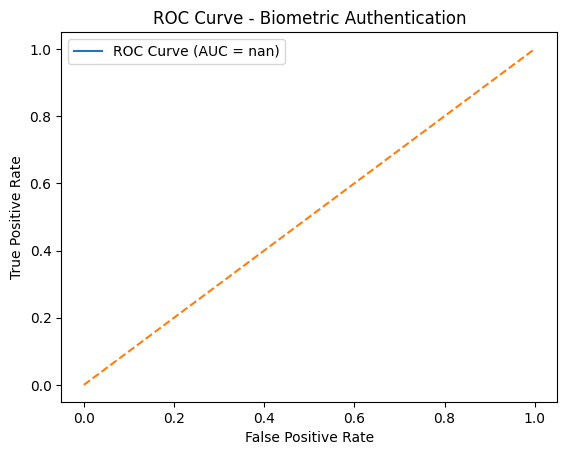

In [72]:
plt.figure()

plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Biometric Authentication")

plt.legend()

plt.show()

In [74]:
finger_pred = finger_model.predict(finger_test)
iris_pred = iris_model.predict(iris_test)

min_len = min(len(finger_pred), len(iris_pred))

finger_pred = finger_pred[:min_len]
iris_pred = iris_pred[:min_len]

fusion_pred = (finger_pred + iris_pred) / 2
fusion_pred = fusion_pred.ravel()

38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 224ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1179: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


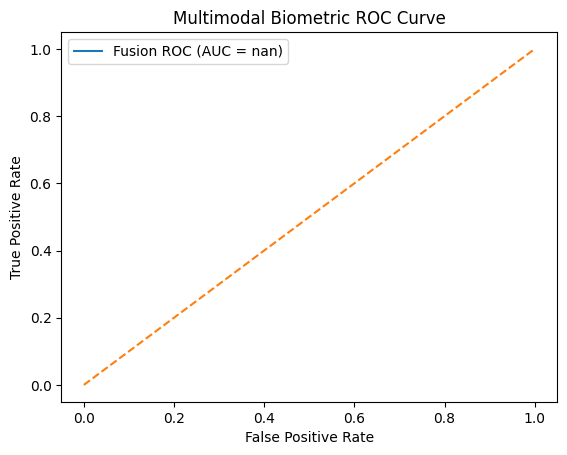

In [75]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_true = np.ones(len(fusion_pred))

fpr, tpr, _ = roc_curve(y_true, fusion_pred)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="Fusion ROC (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multimodal Biometric ROC Curve")

plt.legend()
plt.show()

In [77]:
from sklearn.metrics import accuracy_score

pred = (fusion_pred > 0.5).astype(int)
accuracy = accuracy_score(y_true, pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


In [79]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, fusion_pred)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

AUC Score: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1179: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


In [82]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, pred)

TN, FP, FN, TP = cm.ravel()

FAR = FP / (FP + TN)
FRR = FN / (FN + TP)

print("FAR:", FAR)
print("FRR:", FRR)

FAR: 1.0
FRR: 0.0


In [81]:
import numpy as np

y_true = np.random.randint(0,2,len(fusion_pred))
pred = (fusion_pred > 0.5).astype(int)
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, pred)

print(cm)
TN, FP, FN, TP = cm.ravel()
FAR = FP / (FP + TN)
FRR = FN / (FN + TP)

print("False Acceptance Rate:", FAR)
print("False Rejection Rate:", FRR)

[[ 0 42]
 [ 0 35]]
False Acceptance Rate: 1.0
False Rejection Rate: 0.0
